### Music Recommendation System
Using Tf-Idf and some more things if I want idk

In [ ]:
import numpy as np
import pandas as pd
import gdown

In [ ]:
url = f'https://drive.google.com/file/d/1nZU3l-ZvoCTxUe2rmNOFwra04EGGmwu-/view?usp=sharing'

output = './data/dataset.csv'
gdown.download(url, output, quiet=False)

In [ ]:
df = pd.read_csv("./data/dataset.csv")

In [2]:
df.head(10)

,Unnamed: 0,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4
5,5,Chris Smither,What They Say,24NvptbNKGs6sPy1Vh1O0v,48,2012,acoustic,0.566,0.570,2,-6.420,1,0.0329,0.6880,0.000002,0.0943,0.960,83.403,166240,4
6,6,Matt Wertz,Walking in a Winter Wonderland,0BP7hSvLAG3URGrEvNNbGM,48,2012,acoustic,0.575,0.606,9,-8.197,1,0.0300,0.0119,0.000000,0.0675,0.364,121.083,152307,4
7,7,Green River Ordinance,Dancing Shoes,3Y6BuzQCg9p4yH347Nn8OW,45,2012,acoustic,0.586,0.423,7,-7.459,1,0.0261,0.2520,0.000006,0.0976,0.318,138.133,232373,4
8,8,Jason Mraz,Living in the Moment,3ce7k1L4EkZppZPz1EJWTS,44,2012,acoustic,0.650,0.628,7,-7.160,1,0.0232,0.0483,0.000000,0.1190,0.700,84.141,235080,4
9,9,Boyce Avenue,Heaven,2EKxmYmUdAVXlaHCnnW13o,58,2012,acoustic,0.619,0.280,8,-10.238,0,0.0317,0.7300,0.000000,0.1030,0.292,129.948,250063,4


In [3]:
df = df.drop(columns=['track_id'])

In [4]:
df.artist_name.value_counts().iloc[:10]

artist_name
Traditional                4058
Grateful Dead              2320
Johann Sebastian Bach      2125
Giacomo Meyerbeer          1345
Elvis Presley              1242
Wolfgang Amadeus Mozart    1084
Armin van Buuren           1061
Astor Piazzolla             932
Hans Zimmer                 863
Andrei Krylov               841
Name: count, dtype: int64

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='genre'>

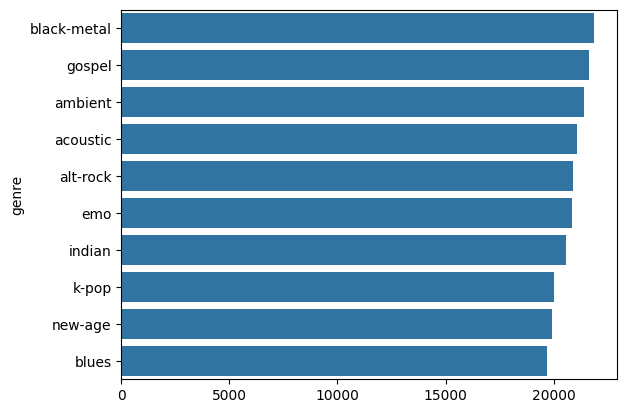

In [6]:
sns.barplot(y=df['genre'].value_counts().iloc[:10].index, x=df['genre'].value_counts().iloc[:10].values)

In [7]:
pop_df = df.sort_values(by='popularity', ascending=False)

<Axes: xlabel='popularity', ylabel='artist_name'>

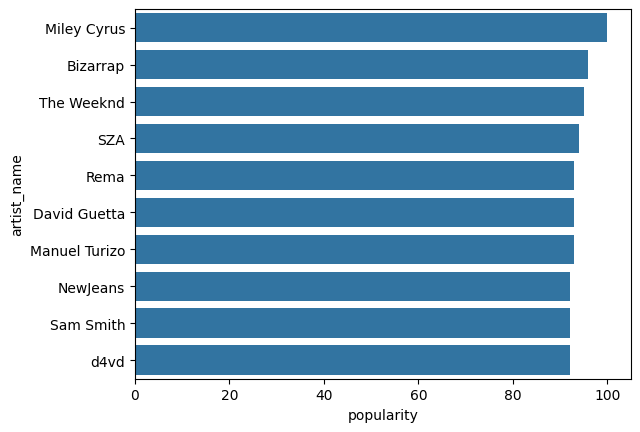

In [8]:
sns.barplot(pop_df[:10], y='artist_name', x='popularity')

<Axes: xlabel='popularity', ylabel='track_name'>

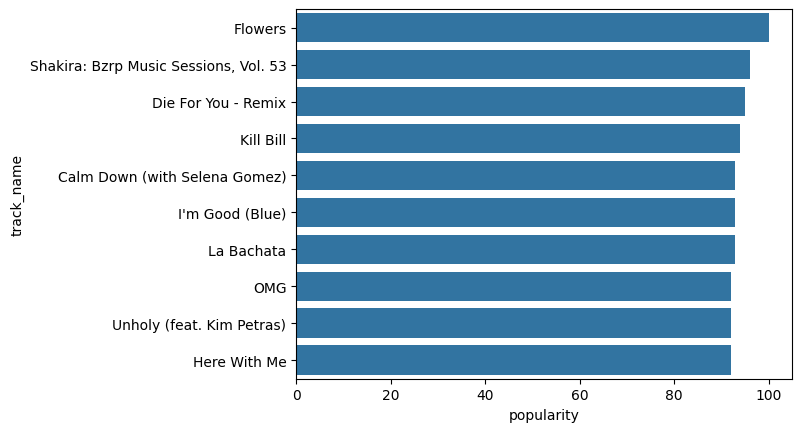

In [9]:
sns.barplot(pop_df[:10], y='track_name', x='popularity')

### data cleaning

In [10]:
df = df.drop_duplicates(subset=['track_name'])

In [11]:
df.artist_name = df.artist_name.str.lower().str.replace(' ', '')

In [12]:
df['genre'] = df['genre'].str.lower().str.replace('[^\w\s]', '', regex=True)

<>:1: SyntaxWarning: invalid escape sequence '\w'
<>:1: SyntaxWarning: invalid escape sequence '\w'
C:\Users\abc\AppData\Local\Temp\ipykernel_13664\783889969.py:1: SyntaxWarning: invalid escape sequence '\w'
  df['genre'] = df['genre'].str.lower().str.replace('[^\w\s]', '', regex=True)


In [13]:
df.isnull().sum()

Unnamed: 0           0
artist_name         12
track_name           1
popularity           0
year                 0
genre                0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
duration_ms          0
time_signature       0
dtype: int64

In [14]:
df = df.dropna(subset=['artist_name', 'track_name'])
df.isna().sum()

Unnamed: 0          0
artist_name         0
track_name          0
popularity          0
year                0
genre               0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
dtype: int64

In [15]:
df['metadata'] = (df['artist_name'] + " ") * 100 + (df['genre'] + " ") * 50 
df['metadata']

0          jasonmraz jasonmraz jasonmraz jasonmraz jasonm...
1          jasonmraz jasonmraz jasonmraz jasonmraz jasonm...
2          joshuahyslop joshuahyslop joshuahyslop joshuah...
3          boyceavenue boyceavenue boyceavenue boyceavenu...
4          andrewbelle andrewbelle andrewbelle andrewbell...
                                 ...                        
1159754    nicolaconte nicolaconte nicolaconte nicolacont...
1159755    nicolaconte nicolaconte nicolaconte nicolacont...
1159759    nicolaconte nicolaconte nicolaconte nicolacont...
1159761    amontobin amontobin amontobin amontobin amonto...
1159763    mo'horizons mo'horizons mo'horizons mo'horizon...
Name: metadata, Length: 882348, dtype: object

In [16]:
from sklearn.metrics.pairwise import linear_kernel
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

In [17]:
tfidf_matrix = tfidf.fit_transform(df['metadata'])
tfidf_matrix.shape

(882348, 60276)

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

cnt = CountVectorizer(stop_words='english')
cnt_matrix = cnt.fit_transform(df['metadata'])

In [19]:
import faiss
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

n_components = 70

# for tfidf
svd = TruncatedSVD(n_components=n_components, random_state=42)
tfidf_vectors = svd.fit_transform(tfidf_matrix)
tfidf_vectors = normalize(tfidf_vectors).astype('float32')
tfidf_idx = faiss.IndexFlatIP(tfidf_vectors.shape[1])
tfidf_idx.add(tfidf_vectors)

# for CountVectorizer 
svd_cnt = TruncatedSVD(n_components=n_components, random_state=42)
cnt_vectors = svd_cnt.fit_transform(cnt_matrix)
cnt_vectors = normalize(cnt_vectors).astype('float32')
cnt_idx = faiss.IndexFlatIP(cnt_vectors.shape[1])
cnt_idx.add(cnt_vectors)

In [20]:
df.reset_index(drop=True)
index_map = pd.Series(df.index, index=df['track_name'])

In [21]:
def recommendations(song, faiss_idx, vectors):
  try:
    idx = index_map[song]
    
    query = vectors[idx:idx+1]

    sim_scores, top_indices = faiss_idx.search(query, 11)

    top_sim_indices = top_indices[0][1:]
    sim_scores = sim_scores[0][1:]
    
    return top_sim_indices, sim_scores
  except KeyError:
    print("song not in dataset")
    return [], []

In [22]:
df2 = df.drop(columns=['track_name', 'artist_name', 'genre', 'Unnamed: 0', 'metadata', 'duration_ms'])

In [23]:
from sklearn.preprocessing import StandardScaler

# for euclidean
euc_vectors = StandardScaler().fit_transform(df2).astype('float32')
index_euc = faiss.IndexFlatL2(euc_vectors.shape[1])
index_euc.add(euc_vectors)

In [24]:
def rec2(song):
  try:
    idx = index_map[song]
    query = euc_vectors[idx:idx+1]

    dist_scores, top_indices = index_euc.search(query, 11)

    top_indices = top_indices[0][1:]
    top_dist_scores = dist_scores[0][1:]
    
    res = df[['track_name', 'artist_name', 'genre']].iloc[top_indices].copy()
    res['euc_score'] = top_dist_scores

    return res.index, top_dist_scores

  except KeyError:
    print("song not in dataset")
    return [], []

In [25]:
dummy_datetime = pd.to_datetime(df['duration_ms'], unit='ms', origin='unix')
df['duration_time'] = dummy_datetime.dt.strftime('%M:%S')

In [26]:
def normal_scores(scores, invert=False):
  mx, mn = scores.max(), scores.min()
  if mx == mn:
    return np.ones_like(scores)
  normalized = (scores - mn) / (mx - mn)
  if invert:
    return 1 - normalized
  else:
    return normalized

In [27]:
def getRecommendation(song, tf_weight = 0.25, cnt_weight=0.25, euc_weight=0.5):
  ind1, tf_scores = recommendations(song, faiss_idx=tfidf_idx, vectors=tfidf_vectors)
  ind2, cnt_scores = recommendations(song, faiss_idx=cnt_idx, vectors=cnt_vectors)
  ind3, euc_scores = rec2(song)
  
  tf_scores = normal_scores(tf_scores)
  cnt_scores = normal_scores(cnt_scores)
  euc_scores = normal_scores(euc_scores, invert=True)
  
  d = {}
  for i in range(len(ind1)):
    if ind1[i] not in d:
      d[ind1[i]] = tf_scores[i] * tf_weight
    else:
      d[ind1[i]] += tf_scores[i] * tf_weight
      
  for i in range(len(ind2)):
    if ind2[i] not in d:
      d[ind2[i]] = cnt_scores[i] * cnt_weight
    else:
      d[ind2[i]] += cnt_scores[i] * cnt_weight
  
  for i in range(len(ind3)):
    if ind3[i] not in d:
      d[ind3[i]] = euc_scores[i] * euc_weight
    else:
      d[ind3[i]] += euc_scores[i] * euc_weight
  d = dict(sorted(d.items(), key=lambda item: item[1], reverse=True))
  top_idx = list(d.keys())[:10]
  res = df[['artist_name', 'track_name', 'genre', 'duration_time']].iloc[top_idx]
  res['score'] = [d[x] for x in top_idx]
  print("EUC", euc_scores)
  print("tfidf", tf_scores)
  print("CNT", cnt_scores)
  return res

In [28]:
df.to_pickle("df.pkl")

faiss.write_index(tfidf_idx, "tfidf_idx.index")
faiss.write_index(cnt_idx, "cnt_idx.index")

np.save('euc_vectors.npy', euc_vectors)

np.save("tfidf_vectors.npy", tfidf_vectors)
np.save("cnt_vectors.npy", cnt_vectors)